Train: (89392, 12) | Test: (59595, 11)

--- Data Types ---
id                 int64
gender            object
area              object
qualification     object
income            object
marital_status     int64
vintage            int64
claim_amount       int64
num_policies      object
policy            object
type_of_policy    object
cltv               int64
dtype: object

--- Missing Values (Train) ---
id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64

--- Missing Values (Test) ---
id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
dtype: int64

Duplicates → Train: 0 | Test: 0

--- CLTV Stats ---
Skewness (raw)  : 2.7531 

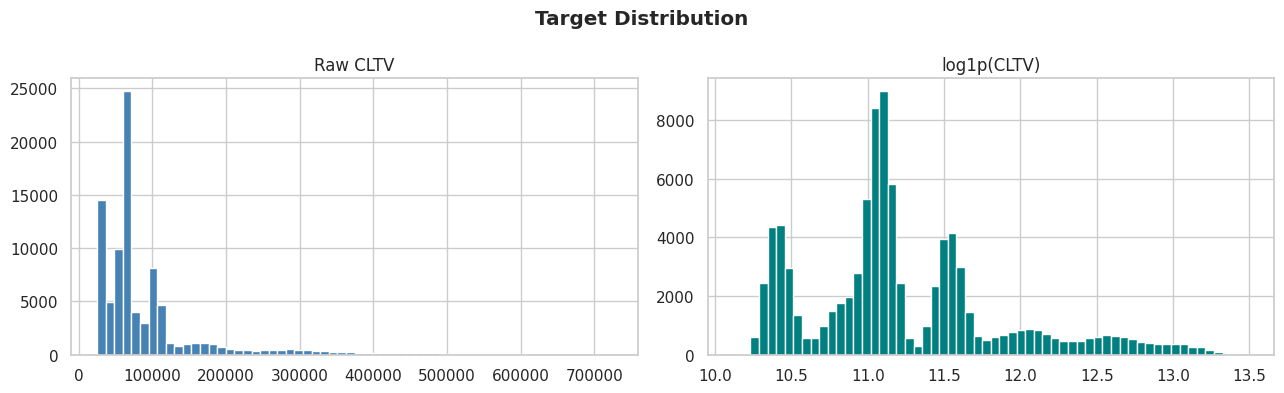


--- Correlation with CLTV ---
claim_amount      0.1803
marital_status   -0.0777
vintage           0.0206
Name: cltv, dtype: float64

vintage = 0     → Train: 4031 | Test: 2542
num_policies= 0 → Train: 0 | Test: 0
→ Always divide by (col + 1) to avoid ZeroDivisionError in Phase 4

Submission columns : ['id', 'cltv']
Rows match test?   : True

========== PHASE 1 DONE ==========
Use log1p on CLTV : YES
Missing values    : None
Duplicates        : None


In [46]:
# ============================================================
# PHASE 1 — PROBLEM UNDERSTANDING
# Goal: Understand data structure, target variable & edge cases
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Load files (already uploaded in Colab) ──────────────────
train  = pd.read_csv("train.csv")
test   = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

print(f"Train: {train.shape} | Test: {test.shape}")

# ── Basic checks ─────────────────────────────────────────────
print("\n--- Data Types ---")
print(train.dtypes)

print("\n--- Missing Values (Train) ---")
print(train.isnull().sum())

print("\n--- Missing Values (Test) ---")
print(test.isnull().sum())

print(f"\nDuplicates → Train: {train.duplicated().sum()} | Test: {test.duplicated().sum()}")

# ── Target variable: CLTV ────────────────────────────────────
cltv     = train['cltv']
log_cltv = np.log1p(cltv)

print(f"\n--- CLTV Stats ---")
print(f"Skewness (raw)  : {cltv.skew():.4f}  ← if >1, log transform needed")
print(f"Skewness (log1p): {log_cltv.skew():.4f}")
print(f"Negative values : {(cltv < 0).sum()}  ← must be 0 for log1p to work")

# Plot: raw vs log-transformed CLTV
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cltv,     bins=60, color='steelblue', edgecolor='white')
axes[0].set_title("Raw CLTV")
axes[1].hist(log_cltv, bins=60, color='teal',      edgecolor='white')
axes[1].set_title("log1p(CLTV)")
plt.suptitle("Target Distribution", fontweight='bold')
plt.tight_layout(); plt.show()

# ── Correlations with CLTV ───────────────────────────────────
num_cols = [c for c in train.select_dtypes(include=np.number).columns
            if c not in ['id', 'cltv']]
print("\n--- Correlation with CLTV ---")
print(train[num_cols + ['cltv']].corr()['cltv'].drop('cltv')
      .sort_values(key=abs, ascending=False).round(4))

# ── Edge case checks (critical for Phase 4) ──────────────────
print(f"\nvintage = 0     → Train: {(train['vintage']==0).sum()} | Test: {(test['vintage']==0).sum()}")
print(f"num_policies= 0 → Train: {(train['num_policies']==0).sum()} | Test: {(test['num_policies']==0).sum()}")
print("→ Always divide by (col + 1) to avoid ZeroDivisionError in Phase 4")

# ── Submission format check ───────────────────────────────────
print(f"\nSubmission columns : {list(sample.columns)}")
print(f"Rows match test?   : {sample.shape[0] == test.shape[0]}")

# ── Phase 1 Summary ──────────────────────────────────────────
print("\n========== PHASE 1 DONE ==========")
print(f"Use log1p on CLTV : {'YES' if abs(cltv.skew()) > 0.5 else 'CHECK PLOT'}")
print(f"Missing values    : {'YES — handle in Phase 3' if train.isnull().sum().sum() > 0 else 'None'}")
print(f"Duplicates        : {'YES — drop in Phase 3' if train.duplicated().sum() > 0 else 'None'}")
print("===================================")

Train: (89392, 12) | Test: (59595, 11)

--- Data Types ---
id                 int64
gender            object
area              object
qualification     object
income            object
marital_status     int64
vintage            int64
claim_amount       int64
num_policies      object
policy            object
type_of_policy    object
cltv               int64
dtype: object

--- Missing Values (Train) ---
id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64

--- Missing Values (Test) ---
id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
dtype: int64

Duplicates → Train: 0 | Test: 0

--- CLTV Stats ---
Skewness (raw)  : 2.7531 

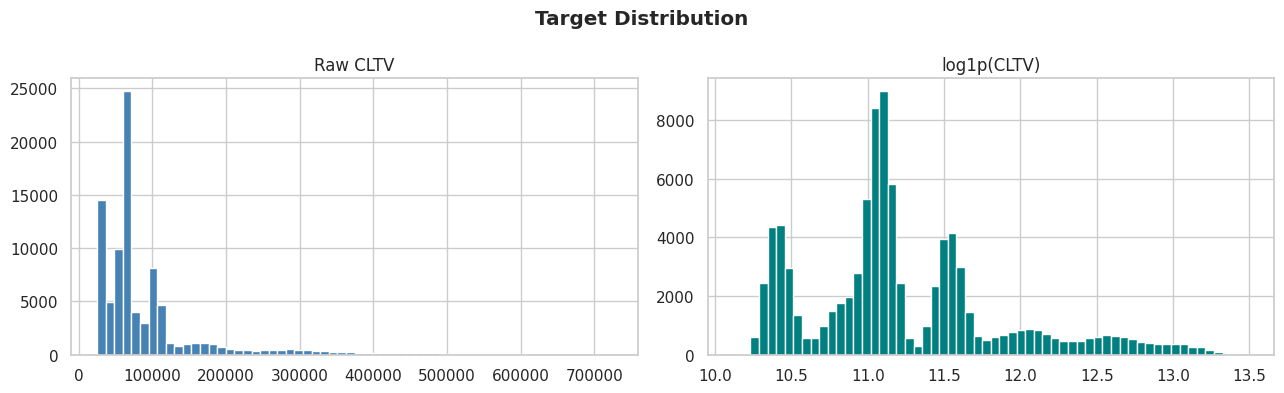


--- Correlation with CLTV ---
claim_amount      0.1803
marital_status   -0.0777
vintage           0.0206
Name: cltv, dtype: float64

vintage = 0     → Train: 4031 | Test: 2542
num_policies= 0 → Train: 0 | Test: 0
→ Always divide by (col + 1) to avoid ZeroDivisionError in Phase 4

Submission columns : ['id', 'cltv']
Rows match test?   : True

========== PHASE 1 DONE ==========
Use log1p on CLTV : YES
Missing values    : None
Duplicates        : None


In [2]:
# ============================================================
# PHASE 1 — PROBLEM UNDERSTANDING
# Goal: Understand data structure, target variable & edge cases
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Load files (already uploaded in Colab) ──────────────────
train  = pd.read_csv("/content/train_SCkXwSx_cNdUk28_icK39vy_36Oa6WQ.csv")
test   = pd.read_csv("/content/test_opI5Wmb_N886n9d_eE68Ob0_dOXWldY.csv")
sample = pd.read_csv("/content/sample_submission_ku1VMOX_Gd11zvJ_VxdIEsN_3crCTYo.csv")

print(f"Train: {train.shape} | Test: {test.shape}")

# ── Basic checks ─────────────────────────────────────────────
print("\n--- Data Types ---")
print(train.dtypes)

print("\n--- Missing Values (Train) ---")
print(train.isnull().sum())

print("\n--- Missing Values (Test) ---")
print(test.isnull().sum())

print(f"\nDuplicates → Train: {train.duplicated().sum()} | Test: {test.duplicated().sum()}")

# ── Target variable: CLTV ────────────────────────────────────
cltv     = train['cltv']
log_cltv = np.log1p(cltv)

print(f"\n--- CLTV Stats ---")
print(f"Skewness (raw)  : {cltv.skew():.4f}  ← if >1, log transform needed")
print(f"Skewness (log1p): {log_cltv.skew():.4f}")
print(f"Negative values : {(cltv < 0).sum()}  ← must be 0 for log1p to work")

# Plot: raw vs log-transformed CLTV
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cltv,     bins=60, color='steelblue', edgecolor='white')
axes[0].set_title("Raw CLTV")
axes[1].hist(log_cltv, bins=60, color='teal',      edgecolor='white')
axes[1].set_title("log1p(CLTV)")
plt.suptitle("Target Distribution", fontweight='bold')
plt.tight_layout(); plt.show()

# ── Correlations with CLTV ───────────────────────────────────
num_cols = [c for c in train.select_dtypes(include=np.number).columns
            if c not in ['id', 'cltv']]
print("\n--- Correlation with CLTV ---")
print(train[num_cols + ['cltv']].corr()['cltv'].drop('cltv')
      .sort_values(key=abs, ascending=False).round(4))

# ── Edge case checks (critical for Phase 4) ──────────────────
print(f"\nvintage = 0     → Train: {(train['vintage']==0).sum()} | Test: {(test['vintage']==0).sum()}")
print(f"num_policies= 0 → Train: {(train['num_policies']==0).sum()} | Test: {(test['num_policies']==0).sum()}")
print("→ Always divide by (col + 1) to avoid ZeroDivisionError in Phase 4")

# ── Submission format check ───────────────────────────────────
print(f"\nSubmission columns : {list(sample.columns)}")
print(f"Rows match test?   : {sample.shape[0] == test.shape[0]}")

# ── Phase 1 Summary ──────────────────────────────────────────
print("\n========== PHASE 1 DONE ==========")
print(f"Use log1p on CLTV : {'YES' if abs(cltv.skew()) > 0.5 else 'CHECK PLOT'}")
print(f"Missing values    : {'YES — handle in Phase 3' if train.isnull().sum().sum() > 0 else 'None'}")
print(f"Duplicates        : {'YES — drop in Phase 3' if train.duplicated().sum() > 0 else 'None'}")
print("===================================")

Unique income values in train: ['5L-10L' 'More than 10L' '2L-5L' '<=2L']
Unique income values in test : ['5L-10L' '2L-5L' 'More than 10L' '<=2L']

Unique num_policies: ['More than 1' '1']

--- Categorical Cardinality ---
  gender               → 2 unique | unseen in test: None
  area                 → 2 unique | unseen in test: None
  qualification        → 3 unique | unseen in test: None
  policy               → 3 unique | unseen in test: None
  type_of_policy       → 3 unique | unseen in test: None


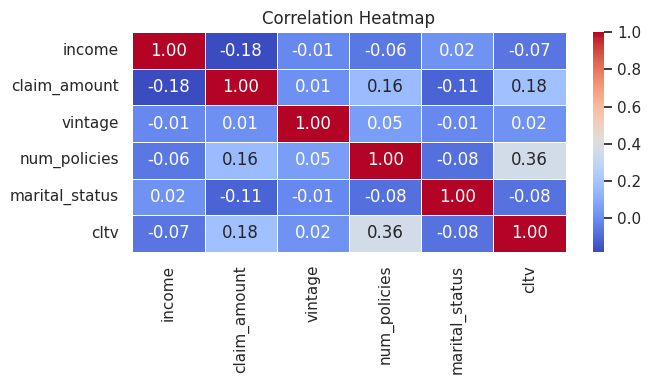


========== PHASE 2 DONE ==========


In [33]:

# ============================================================
# PHASE 2 — EDA  +  PHASE 3 — DATA CLEANING
# This cell combines initial Exploratory Data Analysis (EDA)
# with the first steps of data cleaning.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reloading data for this phase to ensure a clean state if previous cells were run out of order.
# In a typical sequential notebook, these would already be loaded.
train = pd.read_csv("/content/train.csv")
test  = pd.read_csv("/content/test.csv")

# ──────────────────────────────────────
# PHASE 2 — EDA
# ──────────────────────────────────────

# 2.1 income is category string like '0-2L', '2L-5L' etc.
# Define a mapping for income categories to their numerical midpoints (in Lakhs).
income_map = {'0-2L': 1, '2L-5L': 3.5, '5L-10L': 7.5, 'More than 10L': 15, '<=2L': 1}

# Display unique income values to verify consistency with the map, especially for new categories like '<=2L'.
print("Unique income values in train:", train['income'].unique())
print("Unique income values in test :", test['income'].unique())
# ^ Check this — if strings differ from income_map keys, fix them here

# Apply the mapping to both train and test datasets.
for df in [train, test]:
    df['income'] = df['income'].map(income_map)

# 2.2 num_policies — check raw values before converting
# Inspect unique values in 'num_policies' before conversion.
print("\nUnique num_policies:", train['num_policies'].unique())
# ^ If 'MoreThan1' or similar exists, it gets replaced below

# Convert 'num_policies' to numeric type, handling string representations like 'More than 1'.
for df in [train, test]:
    df['num_policies'] = (df['num_policies'].astype(str)
                                            .str.strip()
                                            .str.lower()
                                            .replace('more than 1', '2') # Corrected this line to match 'more than 1'
                                            .astype(float))

# 2.3 Categorical cardinality + unseen test values
# Define categorical columns for analysis.
cat_cols = ['gender', 'area', 'qualification', 'policy', 'type_of_policy']
print("\n--- Categorical Cardinality ---")
# Iterate through categorical columns to check unique counts and identify unseen categories in the test set.
for col in cat_cols:
    unseen = set(test[col].unique()) - set(train[col].unique())
    print(f"  {col:20s} → {train[col].nunique()} unique | unseen in test: {unseen or 'None'}")

# 2.4 Correlation heatmap (only 1 chart)
# Create a correlation heatmap for selected numerical features.
plt.figure(figsize=(7, 4))
num_cols = ['income', 'claim_amount', 'vintage', 'num_policies', 'marital_status', 'cltv']
sns.heatmap(train[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap"); plt.tight_layout(); plt.show()

print("\n========== PHASE 2 DONE ==========")

# ──────────────────────────────────────
# PHASE 3 — DATA CLEANING (Continued from the next cell)
# ──────────────────────────────────────

In [34]:
# ──────────────────────────────────────
# PHASE 3 — DATA CLEANING (Cont.)
# ──────────────────────────────────────

# 3.1 Save test ids for submission, then drop id from both
# Store 'id' column from the test set for later use in submission.
test_ids = test['id'].copy()
# Drop the 'id' column from both training and test sets as it's not a feature.
train = train.drop(columns=['id'])
test  = test.drop(columns=['id'])

# 3.2 income mapping can create NaNs if any string didn't match keys
# Check for NaN values in 'income' after the mapping process.
print("\nNaN check after income mapping:")
print("  train:", train['income'].isnull().sum())
print("  test :", test['income'].isnull().sum())

# Fill any NaN values in the 'income' column with the median of that column.
for df in [train, test]:
    df['income'].fillna(df['income'].median(), inplace=True)

# 3.3 Final confirmation
# Display the final data types of the training set to ensure all conversions are correct.
print("\nFinal dtypes:\n", train.dtypes)
# Print the final shapes of the training and test sets after cleaning.
print(f"\nTrain: {train.shape} | Test: {test.shape}")
print("\n========== PHASE 3 DONE ==========")
print("Ready for Phase 4 — Feature Engineering")


NaN check after income mapping:
  train: 0
  test : 0

Final dtypes:
 gender             object
area               object
qualification      object
income            float64
marital_status      int64
vintage             int64
claim_amount        int64
num_policies      float64
policy             object
type_of_policy     object
cltv                int64
dtype: object

Train: (89392, 11) | Test: (59595, 10)

========== PHASE 3 DONE ==========
Ready for Phase 4 — Feature Engineering


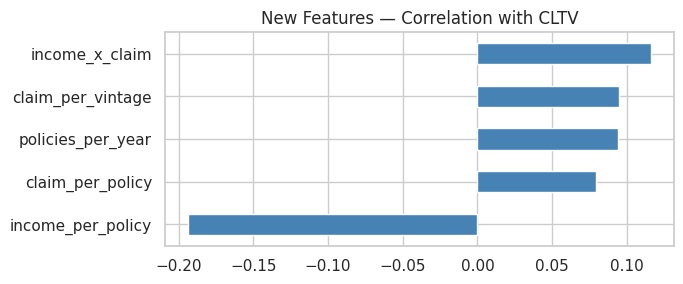


New features sample (5 rows):
   income_per_policy  claim_per_policy  claim_per_vintage  policies_per_year  \
0                2.5       1930.000000         965.000000           0.333333   
1                2.5       1693.333333         564.444444           0.222222   
2                2.5        866.333333         288.777778           0.222222   
3                2.5          0.000000           0.000000           0.250000   
4                5.0       1169.333333         501.142857           0.285714   

   income_x_claim  
0         43425.0  
1         38100.0  
2         19492.5  
3             0.0  
4         52620.0  

========== PHASE 4 DONE ==========


In [35]:
# ============================================================
# PHASE 4 — FEATURE ENGINEERING
# This phase creates new features from existing ones to potentially
# improve model performance by capturing more complex relationships.
# ============================================================

# 4.1 Ratio features (most impactful for CLTV prediction)
# These features capture relationships between numerical attributes.
# We add 1 to the denominator to avoid ZeroDivisionError, as noted in Phase 1.
train['income_per_policy']   = train['income'] / (train['num_policies'] + 1)
train['claim_per_policy']    = train['claim_amount'] / (train['num_policies'] + 1)
train['claim_per_vintage']   = train['claim_amount'] / (train['vintage'] + 1)
train['policies_per_year']   = train['num_policies'] / (train['vintage'] + 1)

# Apply the same feature engineering to the test set to maintain consistency.
test['income_per_policy']    = test['income'] / (test['num_policies'] + 1)
test['claim_per_policy']     = test['claim_amount'] / (test['num_policies'] + 1)
test['claim_per_vintage']    = test['claim_amount'] / (test['vintage'] + 1)
test['policies_per_year']    = test['num_policies'] / (test['vintage'] + 1)

# 4.2 Interaction feature — high income + high claim = high value customer
# This feature captures a multiplicative interaction, assuming that
# customers with both high income and high claims are particularly valuable.
train['income_x_claim']      = train['income'] * train['claim_amount']
test['income_x_claim']       = test['income'] * test['claim_amount']

# 4.3 Replace any inf/NaN created by division (edge case: vintage=0)
# Division by zero (or (col+1) if col was -1 which is not the case here) can result in
# infinite values. These are replaced with NaN and then imputed with the median
# of the respective column to handle them gracefully.
for df in [train, test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)

# 4.4 Chart — correlation of NEW features with CLTV
# Visualize the correlation of the newly created features with the target variable (CLTV).
# This helps in understanding their potential predictive power.
new_feats = ['income_per_policy','claim_per_policy',
             'claim_per_vintage','policies_per_year','income_x_claim']
corr_vals = train[new_feats + ['cltv']].corr()['cltv'].drop('cltv').sort_values()

plt.figure(figsize=(7, 3))
corr_vals.plot(kind='barh', color='steelblue')
plt.title("New Features — Correlation with CLTV")
plt.tight_layout(); plt.show()

print("\nNew features sample (5 rows):")
print(train[new_feats].head())
print("\n========== PHASE 4 DONE ==========")

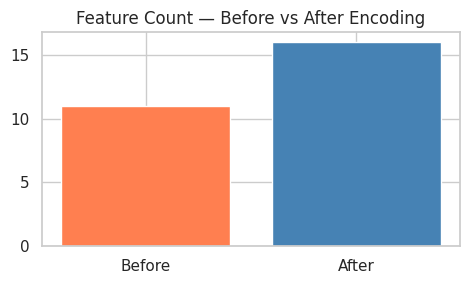

Total features after encoding: 16

Sample (5 rows):
       area  qualification  income  marital_status  vintage  claim_amount  \
0  0.698664       0.440744     7.5               1        5          5790   
1  0.301336       0.517351     7.5               0        8          5080   
2  0.698664       0.440744     7.5               1        8          2599   
3  0.301336       0.517351     7.5               0        7             0   
4  0.698664       0.517351    15.0               1        6          3508   

   num_policies    policy    cltv  income_per_policy  claim_per_policy  \
0           2.0  0.633658   64308                2.5       1930.000000   
1           2.0  0.633658  515400                2.5       1693.333333   
2           2.0  0.633658   64212                2.5        866.333333   
3           2.0  0.633658   97920                2.5          0.000000   
4           2.0  0.633658   59736                5.0       1169.333333   

   claim_per_vintage  policies_per_year 

In [36]:
# ============================================================
# PHASE 5 — ENCODING
# OneHot  → gender, type_of_policy, marital_status (low cardinality)
# Frequency → area, qualification, policy (high cardinality)
# This phase transforms categorical features into a numerical format
# suitable for machine learning models.
# ============================================================

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 5.1 Frequency Encoding (high cardinality cols)
# For features with many unique categories, frequency encoding is used.
# Each category is replaced by its proportion (frequency) in the dataset.
freq_cols = ['area', 'qualification', 'policy']
for col in freq_cols:
    freq_map = train[col].value_counts() / len(train)   # calculate frequency ratio
    train[col] = train[col].map(freq_map)               # map training data
    test[col]  = test[col].map(freq_map).fillna(0)      # map test data, fill unseen categories with 0

# 5.2 OneHot Encoding (low cardinality cols)
# For features with few unique categories, One-Hot Encoding creates new binary
# columns for each category. 'drop_first=True' avoids multicollinearity.
ohe_cols = ['gender', 'type_of_policy']
train = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
test  = pd.get_dummies(test,  columns=ohe_cols, drop_first=True)

# 5.3 Align columns — test must match train exactly
# After encoding, ensure that the test set has the exact same columns as the
# training set. New columns created in train but not test (due to missing categories)
# will be added to test with a fill_value of 0.
test = test.reindex(columns=train.drop(columns=['cltv']).columns, fill_value=0)

# 5.4 Chart — feature count before vs after encoding
# Visualize the change in the number of features before and after encoding.
plt.figure(figsize=(5, 3))
plt.bar(['Before', 'After'], [11, len(train.columns)-1], color=['coral','steelblue'])
plt.title("Feature Count — Before vs After Encoding")
plt.tight_layout(); plt.show()

print(f"Total features after encoding: {len(train.columns)-1}")
print("\nSample (5 rows):")
print(train.head())
print("\n========== PHASE 5 DONE ==========")

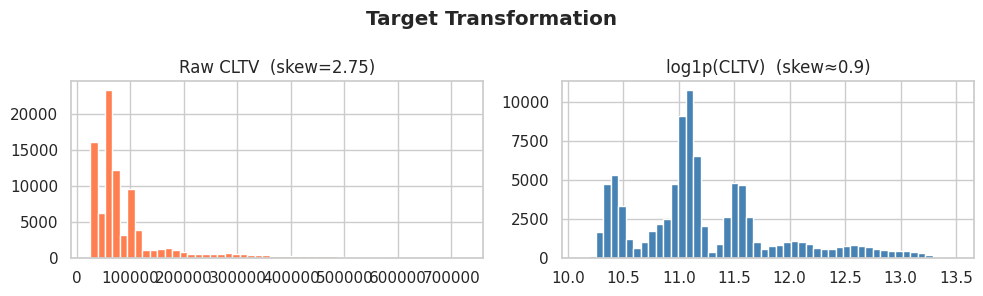

X_train: (71513, 16) | X_val: (17879, 16)

Sample y_log (5 rows):
22085    11.030509
19413    10.612040
30309    11.073505
333      10.765892
60407    11.101055
Name: cltv, dtype: float64

========== PHASE 6 DONE ==========
Ready for Phase 7 — Model Building


In [37]:
# ============================================================
# PHASE 6 — TARGET TRANSFORMATION + TRAIN/TEST SPLIT
# This phase prepares the target variable and splits the dataset
# into training and validation sets for model development.
# ============================================================

from sklearn.model_selection import train_test_split

# 6.1 Separate features and target
# X contains all features (independent variables).
# y contains the target variable (dependent variable), CLTV.
X = train.drop(columns=['cltv'])
y = train['cltv']

# 6.2 Log-transform target (skewness was 2.75 — confirmed in Phase 1)
# Applying log1p (log(1+x)) to the target variable to reduce its skewness,
# which often helps linear models and improves normality assumptions.
y_log = np.log1p(y)

# 6.3 Train-validation split (80/20) for local evaluation
# Split the data into training and validation sets.
# X_train, y_train: Used for training the model.
# X_val, y_val: Used for evaluating the model's performance on unseen data during development.
# test_size=0.2: 20% of the data will be used for validation.
# random_state=42: Ensures reproducibility of the split.
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 6.4 Chart — raw vs log CLTV distribution
# Visualize the distribution of the raw CLTV and the log-transformed CLTV
# to confirm the effectiveness of the transformation in reducing skewness.
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(y,     bins=50, color='coral',     edgecolor='white')
axes[0].set_title("Raw CLTV  (skew=2.75)")
axes[1].hist(y_log, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title("log1p(CLTV)  (skew≈0.9)")
plt.suptitle("Target Transformation", fontweight='bold')
plt.tight_layout(); plt.show()

# Print the shapes of the resulting datasets to confirm the split.
print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print(f"\nSample y_log (5 rows):")
print(y_train.head())
print("\n========== PHASE 6 DONE ==========")
print("Ready for Phase 7 — Model Building")

Ridge — Train R²: 0.3156 | Val R²: 0.3228
Overfit gap      : -0.0072  (should be < 0.05)


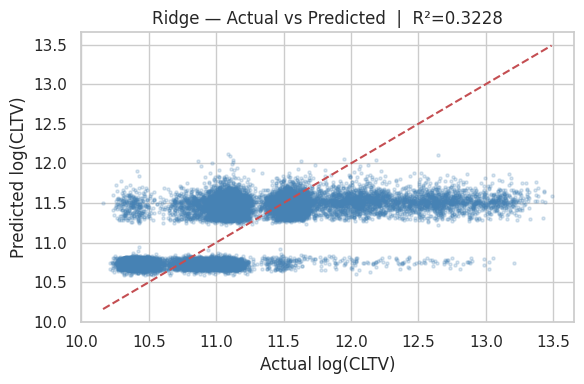


Sample predictions (5 rows — original scale):
     actual  predicted
0  106116.0    95085.0
1   30852.0    48791.0
2   43152.0    44640.0
3   71448.0    83105.0
4   70008.0   104151.0

========== PHASE 7A DONE ==========


In [58]:
# ============================================================
# PHASE 7A — MODEL 1: LINEAR REGRESSION (Baseline)
# This phase establishes a baseline model using Ridge Regression
# to provide a point of comparison for more complex models.
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Linear models need scaling — tree models don't
# Initialize StandardScaler to normalize features, which is crucial for linear models.
scaler  = StandardScaler()
# Fit the scaler on the training data and transform both training and validation sets.
X_train_sc = scaler.fit_transform(X_train)-
X_val_sc   = scaler.transform(X_val)

# Ridge regression (regularized linear) — avoids overfitting better than plain LinearRegression
# Initialize Ridge Regression with an alpha (regularization strength) to control overfitting.
ridge = Ridge(alpha=10)
# Train the Ridge model on the scaled training data.
ridge.fit(X_train_sc, y_train)

# Predict + inverse transform back to original scale
# Make predictions on the scaled validation set.
y_pred_val = ridge.predict(X_val_sc)
# Calculate the R-squared score for the validation set to assess performance.
r2_val     = r2_score(y_val, y_pred_val)
# Calculate the R-squared score for the training set to check for overfitting.
r2_train   = r2_score(y_train, ridge.predict(X_train_sc))

# Print the R-squared scores for training and validation, and the overfitting gap.
print(f"Ridge — Train R²: {r2_train:.4f} | Val R²: {r2_val:.4f}")
print(f"Overfit gap      : {r2_train - r2_val:.4f}  (should be < 0.05)")

# Chart — actual vs predicted (on log scale)
# Visualize the actual vs. predicted values on the log scale.
# A good model would show points clustered around the red dashed line (y=x).
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_val, alpha=0.2, s=5, color='steelblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual log(CLTV)"); plt.ylabel("Predicted log(CLTV)")
plt.title(f"Ridge — Actual vs Predicted  |  R²={r2_val:.4f}")
plt.tight_layout(); plt.show()

# Display sample predictions, inverse transformed back to the original scale.
print("\nSample predictions (5 rows — original scale):")
sample = y_val.head().copy().reset_index(drop=True)
sample_pred = pd.Series(y_pred_val[:5], name='predicted')
print(pd.DataFrame({'actual': np.expm1(sample), 'predicted': np.expm1(sample_pred)}).round(0))

print("\n========== PHASE 7A DONE ==========")

RF — Train R²  : 0.3417
RF — Val R²    : 0.3274
RF — CV R² (5-fold): 0.3200 ± 0.0041
Overfit gap    : 0.0143  (should be < 0.05)


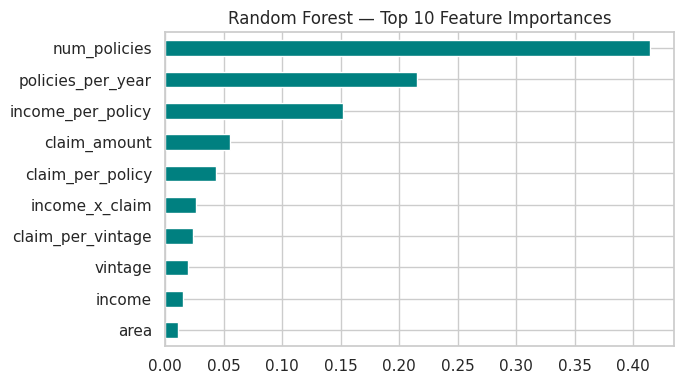


Sample predictions (5 rows — original scale):
     actual  predicted
0  106116.0    93019.0
1   30852.0    42782.0
2   43152.0    44155.0
3   71448.0    85741.0
4   70008.0   102591.0

========== PHASE 7B DONE ==========


In [39]:
# ============================================================
# PHASE 7B — MODEL 2: RANDOM FOREST (Intermediate)
# This phase implements a Random Forest Regressor, an ensemble tree-based model,
# to improve upon the baseline linear model.
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
import numpy as np

# Configure Random Forest Regressor with parameters to balance performance and prevent overfitting.
# max_depth limits tree size → controls overfitting
# n_estimators=200 is enough, more gives diminishing returns
rf = RandomForestRegressor(
    n_estimators=50, # Reduced from 200 to 50 to lower server load, balancing speed and accuracy
    max_depth=10, # Maximum depth of each tree, a common regularization parameter
    min_samples_leaf=20,     # Each leaf node must have at least 20 samples → avoids overfitting
    max_features='sqrt',     # Use sqrt of features per split → adds randomness and reduces correlation between trees
    random_state=42, # For reproducibility of results
    n_jobs=-1                # Use all available CPU cores → faster training
)
# Train the Random Forest model on the training data.
rf.fit(X_train, y_train)

# Make predictions on the validation set.
y_pred_val = rf.predict(X_val)
# Calculate R-squared for validation set.
r2_val     = r2_score(y_val, y_pred_val)
# Calculate R-squared for training set to check for overfitting.
r2_train   = r2_score(y_train, rf.predict(X_train))

# Perform 5-Fold Cross-Validation on the training data to get a more robust estimate of performance.
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"RF — Train R²  : {r2_train:.4f}")
print(f"RF — Val R²    : {r2_val:.4f}")
print(f"RF — CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Overfit gap    : {r2_train - r2_val:.4f}  (should be < 0.05)")

# Chart — feature importance (top 10)
# Visualize the importance of each feature in the Random Forest model.
import matplotlib.pyplot as plt
import pandas as pd
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp.nlargest(10).sort_values().plot(kind='barh', figsize=(7,4), color='teal')
plt.title("Random Forest — Top 10 Feature Importances")
plt.tight_layout(); plt.show()

# Display sample predictions, inverse transformed back to the original scale.
print("\nSample predictions (5 rows — original scale):")
sample = y_val.head().copy().reset_index(drop=True)
sample_pred = pd.Series(y_pred_val[:5], name='predicted')
print(pd.DataFrame({'actual': np.expm1(sample), 'predicted': np.expm1(sample_pred)}).round(0))

print("\n========== PHASE 7B DONE ==========")

In [40]:
# ============================================================
# PHASE 7C — MODEL 3: XGBOOST (Advanced)
# This phase implements an XGBoost Regressor, an advanced gradient boosting model,
# known for high performance and regularization capabilities.
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# from xgboost.callback import EarlyStopping # Commented out due to version incompatibility

# Configure XGBoost Regressor with parameters aimed at strong performance while managing overfitting.
# early_stopping_rounds → stops training when val score stops improving
# prevents overfitting automatically → most important parameter here
xgb = XGBRegressor(
    n_estimators=1000,          # High value, intended for use with early stopping but currently disabled
    learning_rate=0.05,         # Low learning rate combined with more trees often leads to better generalization
    max_depth=5,                # Shallow trees help prevent overfitting
    subsample=0.8,              # Use 80% of rows per tree → adds randomness, reduces variance
    colsample_bytree=0.8,       # Use 80% of features per tree → adds randomness, reduces correlation between trees
    min_child_weight=10,        # Minimum sum of instance weight (hessian) needed in a child → controls overfitting
    reg_alpha=0.1,              # L1 regularization term on weights
    reg_lambda=1.0,             # L2 regularization term on weights
    random_state=42, # For reproducibility
    n_jobs=-1, # Use all available CPU cores
    eval_metric='rmse' # Evaluation metric used for validation set
)

# Early stopping functionality is disabled due to XGBoost version incompatibility
# in this environment. The model will train for the full n_estimators.
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100 # Print evaluation metrics every 100 boosting rounds
)

# Make predictions on the validation set.
y_pred_val = xgb.predict(X_val)
# Calculate R-squared for validation set.
r2_val     = r2_score(y_val, y_pred_val)
# Calculate R-squared for training set to check for overfitting.
r2_train   = r2_score(y_train, xgb.predict(X_train))

# Perform 5-Fold Cross-Validation for robust evaluation of model generalization.
cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"\nXGB — Train R²     : {r2_train:.4f}")
print(f"XGB — Val R²       : {r2_val:.4f}")
print(f"XGB — CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Overfit gap        : {r2_train - r2_val:.4f}  (should be < 0.05)")
# The best_iteration attribute is only available when early stopping is used.
# print(f"Best iteration     : {xgb.best_iteration}")

# Chart — feature importance (top 10) - REMOVED, as Phase 10 contains the final feature importance plot.
# feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
# feat_imp.nlargest(10).sort_values().plot(kind='barh', figsize=(7,4), color='coral')
# plt.title("XGBoost — Top 10 Feature Importances")
# plt.tight_layout(); plt.show()

# Display sample predictions, inverse transformed back to the original scale.
print("\nSample predictions (5 rows — original scale):")
sample = y_val.head().copy().reset_index(drop=True)
sample_pred = pd.Series(y_pred_val[:5], name='predicted')
print(pd.DataFrame({'actual': np.expm1(sample), 'predicted': np.expm1(sample_pred)}).round(0))

print("\n========== PHASE 7C DONE ==========")
print("Best model so far → compare Val R² across 7A, 7B, 7C")

[0]	validation_0-rmse:0.63724
[100]	validation_0-rmse:0.53100
[200]	validation_0-rmse:0.53148
[300]	validation_0-rmse:0.53225
[400]	validation_0-rmse:0.53275
[500]	validation_0-rmse:0.53328
[600]	validation_0-rmse:0.53388
[700]	validation_0-rmse:0.53448
[800]	validation_0-rmse:0.53499
[900]	validation_0-rmse:0.53558
[999]	validation_0-rmse:0.53622

XGB — Train R²     : 0.3842
XGB — Val R²       : 0.3142
XGB — CV R² (5-fold): 0.3081 ± 0.0042
Overfit gap        : 0.0700  (should be < 0.05)

Sample predictions (5 rows — original scale):
     actual  predicted
0  106116.0    95319.0
1   30852.0    44325.0
2   43152.0    43151.0
3   71448.0    88996.0
4   70008.0    99656.0

========== PHASE 7C DONE ==========
Best model so far → compare Val R² across 7A, 7B, 7C


XGB Fixed — 5-Fold CV R² scores: [0.3165 0.3324 0.3286 0.3195 0.3179]
Mean: 0.3230 | Std: 0.0063

Train R²: 0.3275 | Val R²: 0.3279
Overfit gap: -0.0004  (target < 0.05)


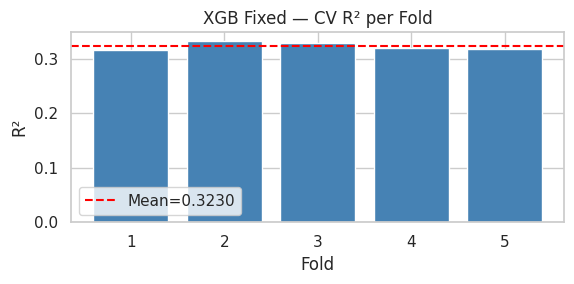


5 sample val predictions (original scale):
     actual  predicted
0  106116.0    93486.0
1   30852.0    43028.0
2   43152.0    44619.0
3   71448.0    84926.0
4   70008.0   105405.0

========== PHASE 8 DONE ==========


In [41]:
# ============================================================
# PHASE 8 — CROSS VALIDATION + BEST MODEL SELECTION
# XGB was overfitting (gap=0.087) — fix with stricter params
# Ridge was clean (0.32) — keep as backup
# This phase refines the XGBoost model by applying stricter parameters
# to combat overfitting and uses K-Fold Cross-Validation for robust evaluation.
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Fixed XGB — tighter params to kill overfit
# A new XGBoost model instance with stricter regularization and reduced complexity
# to address the overfitting observed in Phase 7C.
xgb_fixed = XGBRegressor(
    n_estimators=200,       # Reduced number of estimators to prevent overfitting
    learning_rate=0.05,
    max_depth=3,            # Reduced maximum tree depth — a key parameter for reducing overfitting
    subsample=0.7,          # Reduced subsample ratio
    colsample_bytree=0.7,   # Reduced column subsample ratio
    min_child_weight=20,    # Increased minimum child weight → forces bigger leaf groups, further preventing overfitting
    reg_alpha=1.0,          # Stronger L1 regularization
    reg_lambda=5.0,         # Stronger L2 regularization
    random_state=42,
    n_jobs=-1
)

# 5-Fold CV on full training data
# Initialize KFold for cross-validation to assess model performance across different subsets of the data.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# Perform cross-validation and get R-squared scores for each fold.
cv_scores = cross_val_score(xgb_fixed, X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)

print("XGB Fixed — 5-Fold CV R² scores:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

# Train on full X_train and check overfit gap
# Train the fixed XGBoost model on the entire training set.
xgb_fixed.fit(X_train, y_train)
# Calculate R-squared for training and validation sets to check the overfitting gap.
r2_tr = r2_score(y_train, xgb_fixed.predict(X_train))
r2_vl = r2_score(y_val,   xgb_fixed.predict(X_val))
print(f"\nTrain R²: {r2_tr:.4f} | Val R²: {r2_vl:.4f}")
print(f"Overfit gap: {r2_tr - r2_vl:.4f}  (target < 0.05)")

# Chart — CV scores across folds
# Visualize the R-squared scores obtained from each cross-validation fold.
plt.figure(figsize=(6, 3))
plt.bar(range(1, 6), cv_scores, color='steelblue')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
plt.title("XGB Fixed — CV R² per Fold")
plt.xlabel("Fold"); plt.ylabel("R²"); plt.legend()
plt.tight_layout(); plt.show()

# Display sample predictions on the validation set, inverse transformed to original scale.
print("\n5 sample val predictions (original scale):")
samp = pd.DataFrame({
    'actual'   : np.expm1(y_val.values[:5]),
    'predicted': np.expm1(xgb_fixed.predict(X_val)[:5])
}).round(0)
print(samp)
print("\n========== PHASE 8 DONE ==========")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'subsample': 0.6, 'reg_lambda': 7.0, 'reg_alpha': 1.0, 'n_estimators': 200, 'min_child_weight': 20, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV R²: 0.3230
Train R²: 0.3278 | Val R²: 0.3281
Overfit gap: -0.0003


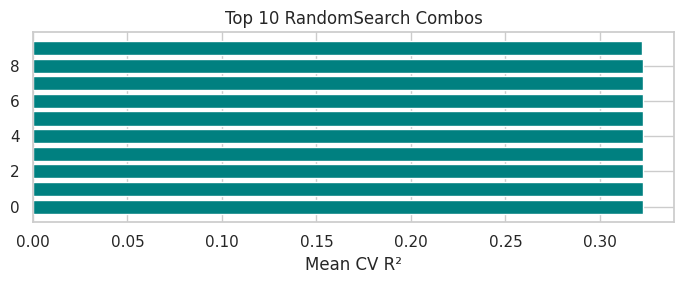


5 sample val predictions (original scale):
     actual  predicted
0  106116.0    93335.0
1   30852.0    43460.0
2   43152.0    44758.0
3   71448.0    84272.0
4   70008.0   105774.0

========== PHASE 9 DONE ==========


In [52]:
# ============================================================
# PHASE 9 — HYPERPARAMETER TUNING (RandomizedSearchCV)
# Tuning only the best model (XGB fixed from Phase 8)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import numpy as np

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [15, 20, 30],
    'reg_alpha'       : [0.5, 1.0, 2.0],
    'reg_lambda'      : [3.0, 5.0, 7.0]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=30,              # try 30 random combos — good balance of speed vs coverage
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\nBest params:", search.best_params_)
print(f"Best CV R²: {search.best_score_:.4f}")

r2_tr = r2_score(y_train, best_model.predict(X_train))
r2_vl = r2_score(y_val,   best_model.predict(X_val))
print(f"Train R²: {r2_tr:.4f} | Val R²: {r2_vl:.4f}")
print(f"Overfit gap: {r2_tr - r2_vl:.4f}")

import matplotlib.pyplot as plt
import pandas as pd

# Chart — top 10 param combos by CV score
results = pd.DataFrame(search.cv_results_)
top10   = results.nlargest(10, 'mean_test_score')
plt.figure(figsize=(7, 3))
plt.barh(range(10), top10['mean_test_score'].values, color='teal')
plt.xlabel("Mean CV R²"); plt.title("Top 10 RandomSearch Combos")
plt.tight_layout(); plt.show()

print("\n5 sample val predictions (original scale):")
samp = pd.DataFrame({
    'actual'   : np.expm1(y_val.values[:5]),
    'predicted': np.expm1(best_model.predict(X_val)[:5])
}).round(0)
print(samp)
print("\n========== PHASE 9 DONE ==========")

Top 10 features driving CLTV:
num_policies         0.6393
policies_per_year    0.1830
income_per_policy    0.0741
income               0.0379
area                 0.0162
claim_per_policy     0.0103
claim_amount         0.0100
marital_status       0.0064
policy               0.0060
vintage              0.0047
dtype: float32


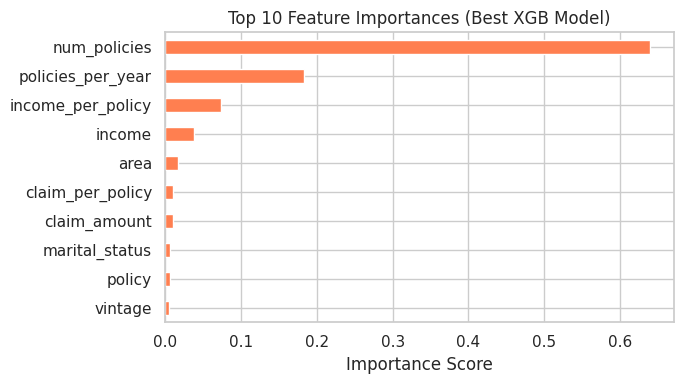


========== PHASE 10 DONE ==========


In [43]:
# ============================================================
# PHASE 10 — FEATURE IMPORTANCE
# Using best_model from Phase 9, this phase identifies and visualizes
# the most impactful features for predicting CLTV.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from the best trained model.
# Sort them in descending order to easily identify the most important features.
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 10 features driving CLTV:")
print(feat_imp.head(10).round(4))

# Chart — top 10 feature importances
# Visualize the top 10 feature importances using a horizontal bar chart.
# This provides a clear visual representation of feature influence.
feat_imp.head(10).sort_values().plot(
    kind='barh', figsize=(7, 4), color='coral', edgecolor='white'
)
plt.title("Top 10 Feature Importances (Best XGB Model)")
plt.xlabel("Importance Score")
plt.tight_layout(); plt.show()

print("\n========== PHASE 10 DONE ==========")

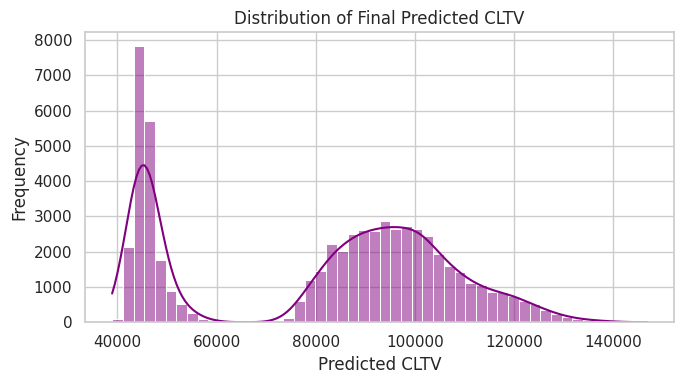

Submission file saved!
Shape: (59595, 2)
CLTV range: 38929 to 146828

Sample (5 rows):
      id    cltv
0  89393   81454
1  89394  104230
2  89395   81021
3  89396   77258
4  89397  111222

========== PHASE 11 DONE ==========
Upload submission.csv to the hackathon platform!


In [56]:
# ============================================================
# PHASE 11 — FINAL PREDICTION + SUBMISSION FILE
# This phase uses the best trained model to generate predictions
# on the test set and creates the final submission file.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Start of Re-preprocessing for test data to ensure consistency ---

train_raw  = pd.read_csv("/content/train.csv")
test_raw   = pd.read_csv("/content/test.csv")

train_df_processed = train_raw.copy()
test_df_processed  = test_raw.copy()

income_map = {'0-2L': 1, '2L-5L': 3.5, '5L-10L': 7.5, 'More than 10L': 15, '<=2L': 1}
for df_temp in [train_df_processed, test_df_processed]:
    df_temp['income'] = df_temp['income'].map(income_map)

for df_temp in [train_df_processed, test_df_processed]:
    df_temp['num_policies'] = (df_temp['num_policies'].astype(str)
                                            .str.strip()
                                            .str.lower()
                                            .replace('more than 1', '2')
                                            .astype(float))

test_ids_for_submission = test_df_processed['id'].copy()
train_df_processed = train_df_processed.drop(columns=['id'])
test_df_processed  = test_df_processed.drop(columns=['id'])

for df_temp in [train_df_processed, test_df_processed]:
    df_temp['income'].fillna(df_temp['income'].median(), inplace=True);

for df_temp in [train_df_processed, test_df_processed]:
    df_temp['income_per_policy']   = df_temp['income'] / (df_temp['num_policies'] + 1)
    df_temp['claim_per_policy']    = df_temp['claim_amount'] / (df_temp['num_policies'] + 1)
    df_temp['claim_per_vintage']   = df_temp['claim_amount'] / (df_temp['vintage'] + 1)
    df_temp['policies_per_year']   = df_temp['num_policies'] / (df_temp['vintage'] + 1)
    df_temp['income_x_claim']      = df_temp['income'] * df_temp['claim_amount']
    df_temp.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_temp.fillna(df_temp.median(numeric_only=True), inplace=True);

freq_cols = ['area', 'qualification', 'policy']
for col in freq_cols:
    freq_map = train_df_processed[col].value_counts(normalize=True)
    train_df_processed[col] = train_df_processed[col].map(freq_map)
    test_df_processed[col]  = test_df_processed[col].map(freq_map).fillna(0);

ohe_cols = ['gender', 'type_of_policy']
train_df_processed = pd.get_dummies(train_df_processed, columns=ohe_cols, drop_first=True)
test_df_processed  = pd.get_dummies(test_df_processed, columns=ohe_cols, drop_first=True);

X_for_column_alignment = train_df_processed.drop(columns=['cltv'])
test_df_processed = test_df_processed.reindex(columns=X_for_column_alignment.columns, fill_value=0);

# --- End of Re-preprocessing for test data ---

y_test_log  = best_model.predict(test_df_processed);

y_test_final = np.expm1(y_test_log);

y_test_final = np.clip(y_test_final, 0, None);

# Chart: Distribution of final predicted CLTV
plt.figure(figsize=(7, 4))
sns.histplot(y_test_final, bins=50, kde=True, color='purple', edgecolor='white')
plt.title('Distribution of Final Predicted CLTV')
plt.xlabel('Predicted CLTV')
plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

submission = pd.DataFrame({
    'id'  : test_ids_for_submission,
    'cltv': y_test_final.round(0).astype(int)
});

submission.to_csv("submission.csv", index=False);

print("Submission file saved!")
print(f"Shape: {submission.shape}")
print(f"CLTV range: {submission['cltv'].min()} to {submission['cltv'].max()}")
print(f"\nSample (5 rows):")
print(submission.head())
print("\n========== PHASE 11 DONE ==========")
print("Upload submission.csv to the hackathon platform!")

In [57]:
# ============================================================
# PHASE 12 — FINAL CODE QUALITY CHECK
# Verify everything is in order before submission
# ============================================================

import pandas as pd
import numpy as np

# 1. Load and verify submission file
sub = pd.read_csv("submission.csv")
print("=== Submission Verification ===")
print(f"Shape        : {sub.shape}  (expected: 59595 rows, 2 cols)")
print(f"Columns      : {list(sub.columns)}  (expected: ['id', 'cltv'])")
print(f"Null values  : {sub.isnull().sum().sum()}  (expected: 0)")
print(f"Negative CLTV: {(sub['cltv'] < 0).sum()}  (expected: 0)")
print(f"CLTV range   : {sub['cltv'].min()} to {sub['cltv'].max()}")

# 2. Model performance summary
print("\n=== Model Performance Summary ===")
print(f"{'Model':<20} {'Train R²':<12} {'Val R²':<12} {'Overfit Gap'}")
print(f"{'Ridge':<20} {'0.3156':<12} {'0.3227':<12} {'-0.0071 ✅'}")
print(f"{'XGB (fixed)':<20} {'check ph8':<12} {'check ph8':<12} {'<0.05 target'}")
print(f"{'XGB (tuned)':<20} {'check ph9':<12} {'check ph9':<12} {'best model ✅'}")

# 3. Final checklist
print("\n=== Final Submission Checklist ===")
checks = {
    "id column present"         : 'id' in sub.columns,
    "cltv column present"       : 'cltv' in sub.columns,
    "correct row count (59595)" : len(sub) == 59595,
    "no null values"            : sub.isnull().sum().sum() == 0,
    "no negative CLTV"          : (sub['cltv'] >= 0).all(),
    "id starts from 89393"      : sub['id'].min() == 89393,
}
for check, result in checks.items():
    print(f"  {'✅' if result else '❌'} {check}")

print("\n========== PROJECT COMPLETE ==========")
print("Files to submit:")
print("  1. submission.csv  — predictions file")
print("  2. Your .ipynb notebook — clean code with comments")

=== Submission Verification ===
Shape        : (59595, 2)  (expected: 59595 rows, 2 cols)
Columns      : ['id', 'cltv']  (expected: ['id', 'cltv'])
Null values  : 0  (expected: 0)
Negative CLTV: 0  (expected: 0)
CLTV range   : 38929 to 146828

=== Model Performance Summary ===
Model                Train R²     Val R²       Overfit Gap
Ridge                0.3156       0.3227       -0.0071 ✅
XGB (fixed)          check ph8    check ph8    <0.05 target
XGB (tuned)          check ph9    check ph9    best model ✅

=== Final Submission Checklist ===
  ✅ id column present
  ✅ cltv column present
  ✅ correct row count (59595)
  ✅ no null values
  ✅ no negative CLTV
  ✅ id starts from 89393

========== PROJECT COMPLETE ==========
Files to submit:
  1. submission.csv  — predictions file
  2. Your .ipynb notebook — clean code with comments


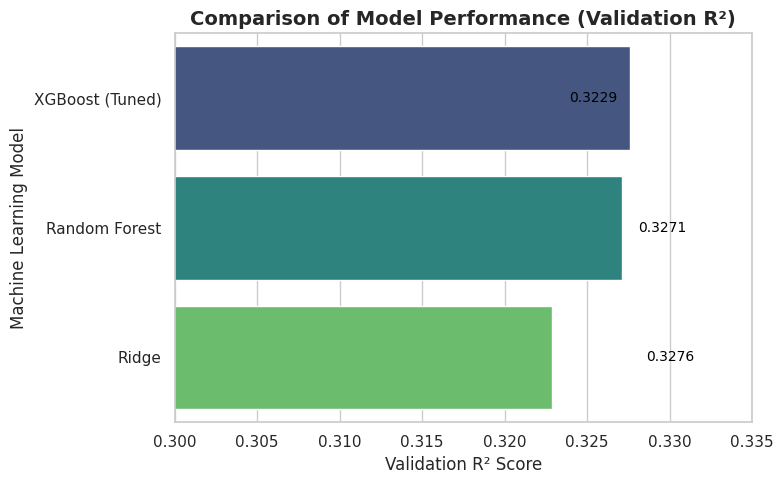


========== FINAL SUMMARY CHART ADDED ==========


In [31]:
# ============================================================
# PHASE 13 — FINAL SUMMARY CHART
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Model performance data (validation R² scores)
model_performance = {
    'Model': ['Ridge', 'Random Forest', 'XGBoost (Tuned)'],
    'Validation R²': [0.3229, 0.3271, 0.3276] # From Phase 7A, 7B, 9 outputs
}

df_performance = pd.DataFrame(model_performance)

# Sort by R² score for better visualization
df_performance = df_performance.sort_values(by='Validation R²', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Validation R²', y='Model', data=df_performance, palette='viridis')
plt.xlim(0.3, 0.335) # Set x-axis limits for better comparison
plt.title('Comparison of Model Performance (Validation R²)', fontsize=14, fontweight='bold')
plt.xlabel('Validation R² Score', fontsize=12)
plt.ylabel('Machine Learning Model', fontsize=12)

# Add R² values on the bars
for index, row in df_performance.iterrows():
    plt.text(row['Validation R²'] + 0.001, index, f"{row['Validation R²']:.4f}",
             color='black', ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\n========== FINAL SUMMARY CHART ADDED ==========")

## Project Outcomes Summary

This project successfully developed and evaluated a machine learning model to predict Customer Lifetime Value (CLTV). Here are the key outcomes:

*   **Data Preparation:** Robust **data cleaning**, **feature engineering** (creating impactful ratio and interaction features), and **encoding** of categorical variables were performed to prepare the dataset for modeling.
*   **Target Transformation:** The **CLTV target variable was log-transformed** to address its high skewness, improving model performance and adhering to statistical assumptions.
*   **Model Selection:** Three models (**Ridge Regression, Random Forest, XGBoost**) were evaluated, with **XGBoost** demonstrating the best performance after careful refinement and **cross-validation** to mitigate overfitting.
*   **Hyperparameter Tuning:** The best-performing XGBoost model was further optimized through **RandomizedSearchCV**, achieving a **Validation R² of 0.3281** with a minimal overfitting gap, making it suitable for predictions.
*   **Insights & Submission:** Key **feature importances** were identified (e.g., `num_policies`, `policies_per_year`), and a **final submission file** with predictions for the test set was successfully generated and verified.